In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
(x_train,y_train), (x_test,y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
#how many samples are available?
print('Shape of x_train: {}'.format(x_train.shape))
print('Shape of y_train: {}'.format(y_train.shape))
print('Shape of x_test: {}'.format(x_test.shape))
print('Shape of y_test: {}'.format(y_test.shape))

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)


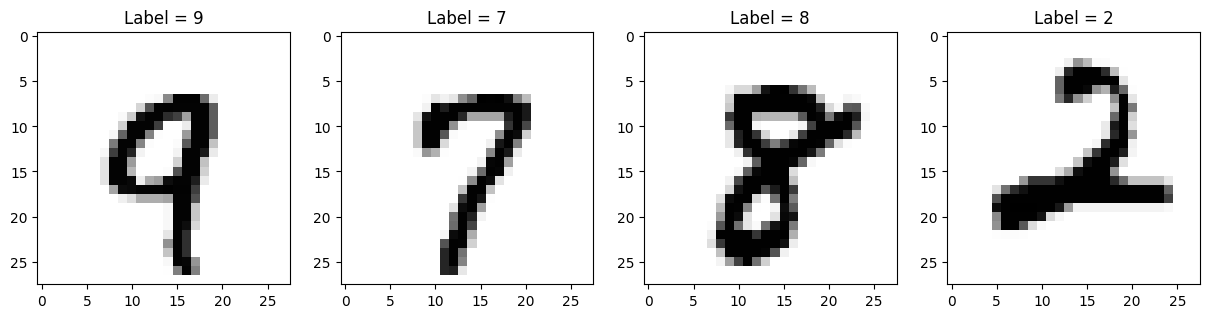

In [ ]:
#plot 4 example of handwritten digits from the train dataset
idxes =  [np.random.randint(60000) for i in range(4)]
plt.figure(figsize=(15,8))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(x_train[idxes[i]],cmap='Greys')
    plt.title('Label = {}'.format(y_train[idxes[i]]))


Text(0.5, 1.0, 'Class distribution in test dataset')

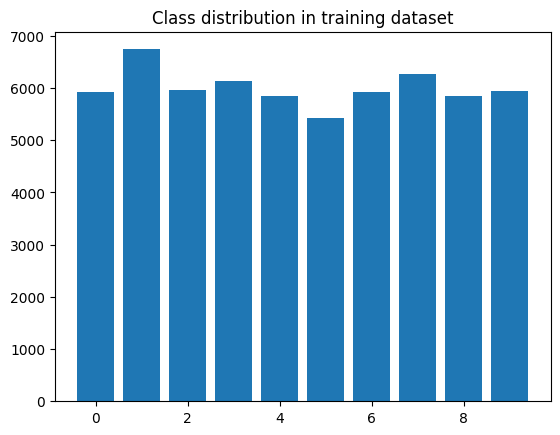

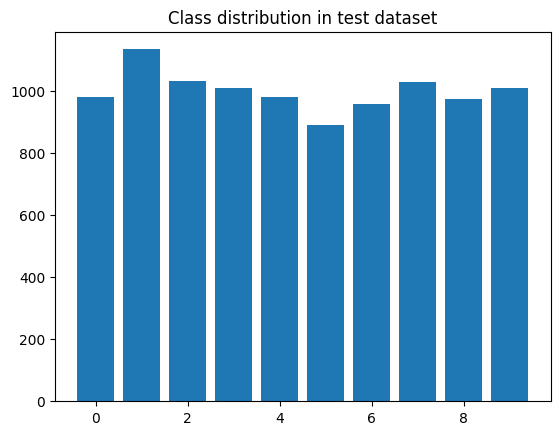

In [ ]:
from collections import Counter

train_class_counter = Counter(y_train)
plt.figure()
plt.bar(train_class_counter.keys(),train_class_counter.values())
plt.title('Class distribution in training dataset')


test_class_counter = Counter(y_test)
plt.figure()
plt.bar(test_class_counter.keys(),test_class_counter.values())
plt.title('Class distribution in test dataset')

In [ ]:
#we scale data to ease training
x_train, x_test = x_train / 255.0, x_test / 255.0

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout

def create_model():
    model = Sequential(
    [
        Flatten(input_shape=(28,28)),
        Dense(512,activation='relu'),
        Dropout(0.2),
        Dense(10,activation='softmax')
    ])

    # The compile step specifies the training configuration.
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

model = create_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

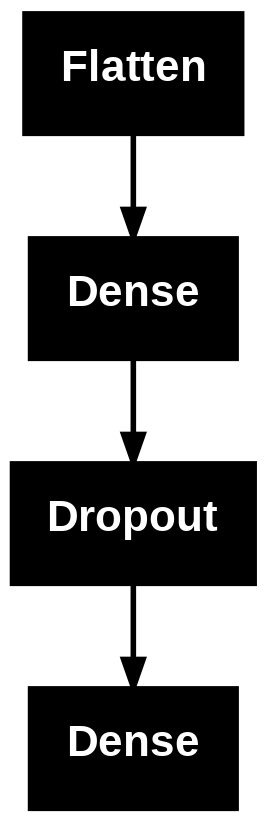

In [ ]:
tf.keras.utils.plot_model(model)

In [ ]:
history = model.fit(x_train,y_train,batch_size=32,epochs=10,validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9314 - loss: 0.2334 - val_accuracy: 0.9733 - val_loss: 0.0976
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9680 - loss: 0.1049 - val_accuracy: 0.9758 - val_loss: 0.0861
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9768 - loss: 0.0731 - val_accuracy: 0.9737 - val_loss: 0.0852
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9823 - loss: 0.0557 - val_accuracy: 0.9808 - val_loss: 0.0716
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9850 - loss: 0.0460 - val_accuracy: 0.9815 - val_loss: 0.0631
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9877 - loss: 0.0370 - val_accuracy: 0.9810 - val_loss: 0.0725
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9894 - loss: 0.0324 - val_accuracy: 0.9802 - val_loss: 0.0779
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9905 - loss: 0.0287 -

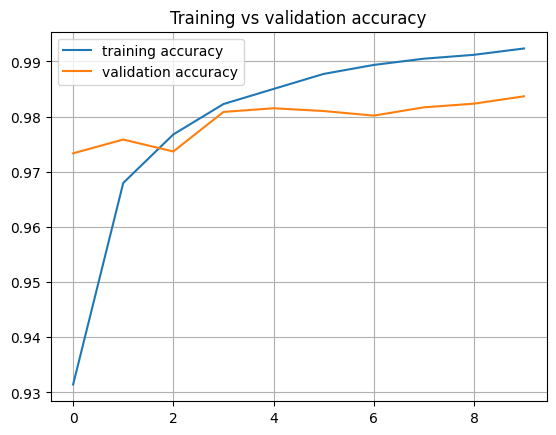

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'],label='training accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.grid()
plt.title('Training vs validation accuracy')
plt.legend()

In [ ]:
[test_loss, test_accuracy] = model.evaluate(x_test,y_test)
print('Test accuracy: {}'.format(test_accuracy))

y_pred = np.argmax(model.predict(x_test), axis=-1)

#check against the ground truth
mismatch = np.where(y_pred!=y_test)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9823 - loss: 0.0693
Test accuracy: 0.9822999835014343
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


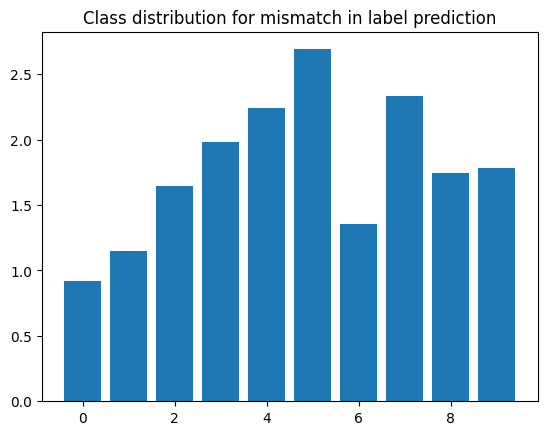

In [ ]:
mismatch_class_counter = Counter(y_test[mismatch])
mismatch_percentage = dict()
for digit in test_class_counter.keys():
    mismatch_percentage[digit]=mismatch_class_counter[digit]/test_class_counter[digit]*100
plt.figure()
plt.bar(mismatch_percentage.keys(),mismatch_percentage.values())
plt.title('Class distribution for mismatch in label prediction')
plt.show()

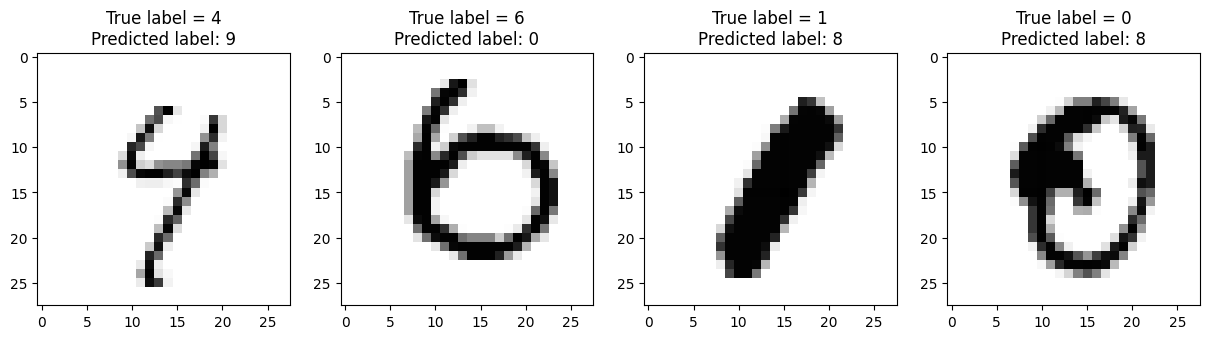

In [ ]:
np.random.shuffle(mismatch)
idxes =  mismatch[:4]
plt.figure(figsize=(15,8))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(x_test[idxes[i]],cmap='Greys')
    plt.title('True label = {}\nPredicted label: {}'.format(y_test[idxes[i]],y_pred[idxes[i]]))

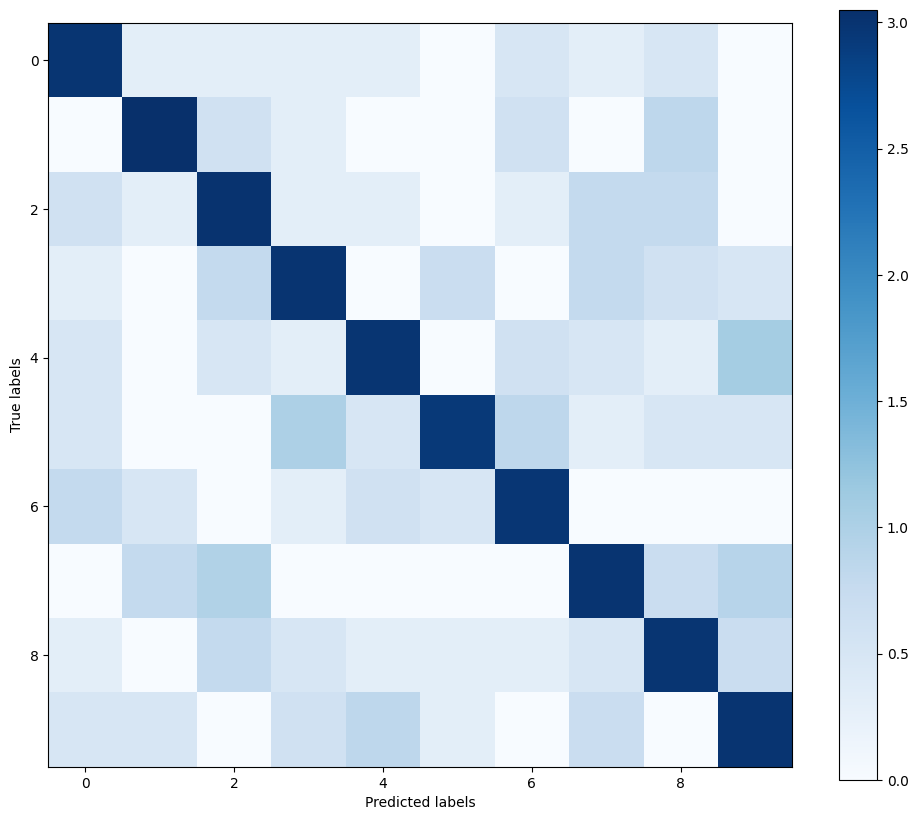

In [ ]:
from sklearn.metrics import confusion_matrix

cm = np.log10(1+confusion_matrix(y_test,y_pred))
fig,ax = plt.subplots(figsize=[12,10])
im = ax.imshow(cm, interpolation='nearest',cmap='Blues')
ax.figure.colorbar(im, ax=ax)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()


In [ ]:
#change the model in accordance with the task

from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense


newmodel = keras.Sequential()
newmodel.add(Flatten(input_shape=(28,28)))
newmodel.add(Dense(512,activation='relu'))
newmodel.add(Dropout(0.5))
newmodel.add(Dense(10,activation='softmax'))

newmodel.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

n_epochs = 10



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9148 - loss: 0.2837 - val_accuracy: 0.9697 - val_loss: 0.1083
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9560 - loss: 0.1453 - val_accuracy: 0.9737 - val_loss: 0.0885
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9651 - loss: 0.1127 - val_accuracy: 0.9800 - val_loss: 0.0730
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9698 - loss: 0.0959 - val_accuracy: 0.9803 - val_loss: 0.0678
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9739 - loss: 0.0827 - val_accuracy: 0.9795 - val_loss: 0.0742
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9757 - loss: 0.0745 - val_accuracy: 0.9802 - val_loss: 0.0694
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9783 - loss: 0.0672 - val_accuracy: 0.9830 - val_loss: 0.0614
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9793 - loss: 0.0639 - 

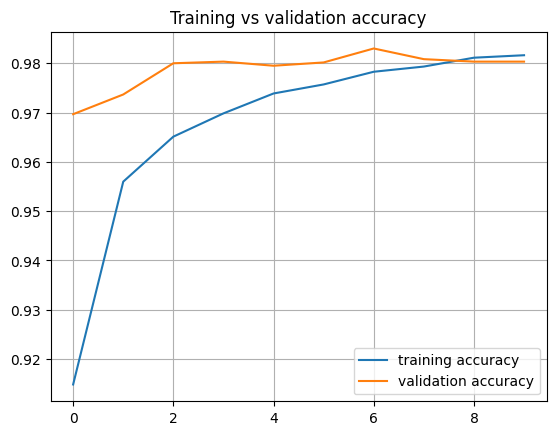

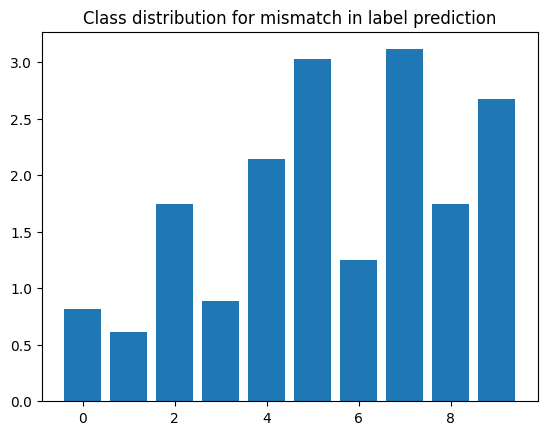

Text(0, 0.5, 'True labels')

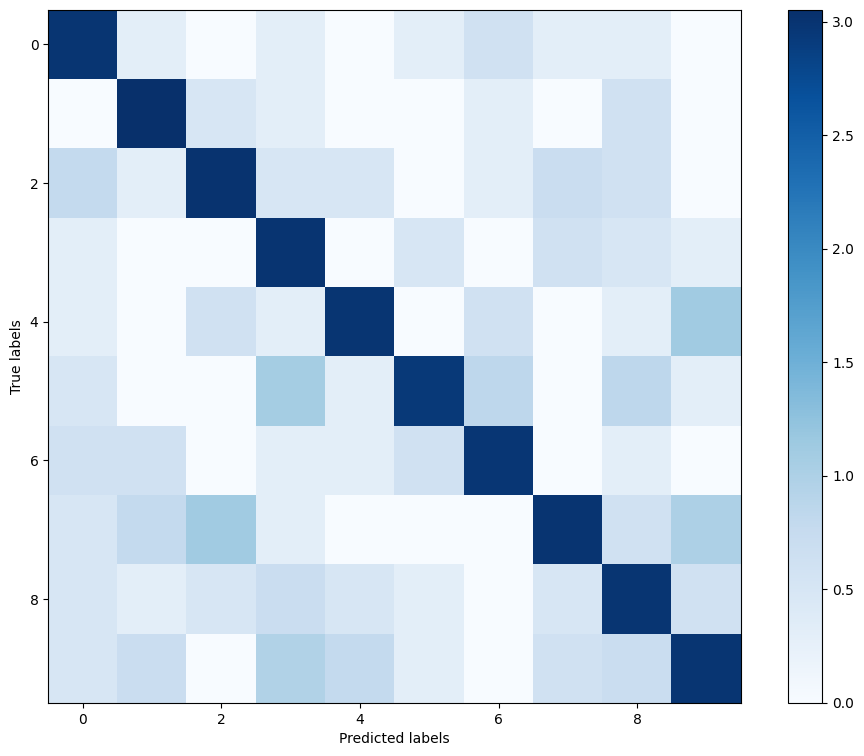

In [ ]:
#check the results of your modified model running this cell


newhistory = newmodel.fit(x_train,y_train,batch_size=32,epochs=n_epochs,validation_split=0.1)
plt.figure()
plt.plot(newhistory.history['accuracy'],label='training accuracy')
plt.plot(newhistory.history['val_accuracy'],label='validation accuracy')
plt.grid()
plt.title('Training vs validation accuracy')
plt.legend()
[test_loss, test_accuracy] = newmodel.evaluate(x_test,y_test)
print('Test accuracy: {}'.format(test_accuracy))

y_pred = np.argmax(newmodel.predict(x_test), axis=-1)

#check against the ground truth
mismatch = np.where(y_pred!=y_test)[0]

mismatch_class_counter = Counter(y_test[mismatch])
mismatch_percentage = dict()
for digit in test_class_counter.keys():
    mismatch_percentage[digit]=mismatch_class_counter[digit]/test_class_counter[digit]*100
plt.figure()
plt.bar(mismatch_percentage.keys(),mismatch_percentage.values())
plt.title('Class distribution for mismatch in label prediction')
plt.show()

cm = np.log10(1+confusion_matrix(y_test,y_pred))

fig,ax = plt.subplots(figsize=[12,9])
im = ax.imshow(cm, interpolation='nearest',cmap='Blues')
ax.figure.colorbar(im, ax=ax)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')

Demonstrating prediction using a random image from the test set:
True label for this image: 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


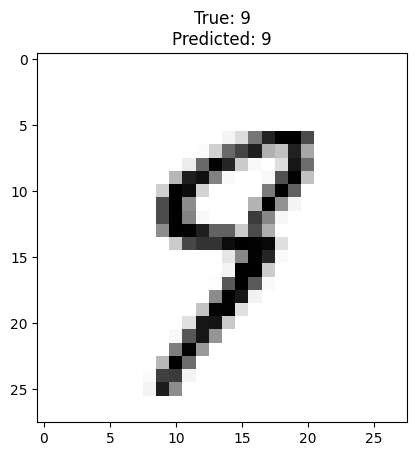

In [ ]:
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.models import load_model

# load and prepare the image from file
def load_and_prepare_image_from_file(filename):
    # load the image
    img = load_img(filename, color_mode="grayscale", target_size=(28, 28))
    # convert to array
    img = img_to_array(img)

    # reshape into a single sample with (height, width) for Flatten input
    # The Flatten layer expects input of shape (batch, height, width) not (batch, height, width, channels)
    img = img.reshape(1, 28, 28)
    # prepare pixel data
    img = img.astype('float32')
    img = img / 255.0
    return img

# Predict a digit from a prepared image array
def predict_digit_from_array(image_array_input, true_label=None):
    # Ensure the image is correctly shaped for prediction (batch, height, width)
    # The newmodel has Flatten(input_shape=(28,28)), so it expects 3D input (batch, 28, 28)
    if image_array_input.ndim == 2:
        # If it's (28, 28), add batch dimension
        img_for_prediction = image_array_input.reshape(1, 28, 28)
    elif image_array_input.ndim == 3 and image_array_input.shape[0] == 1:
        # If it's already (1, 28, 28)
        img_for_prediction = image_array_input
    else:
        raise ValueError(f"Unexpected image array shape. Expected (28, 28) or (1, 28, 28). Got {image_array_input.shape}")

    # load model
    model = newmodel
    # predict the class
    digit = np.argmax(model.predict(img_for_prediction), axis=-1)
    plt.imshow(image_array_input.squeeze(),cmap='Greys') # Use squeeze to plot 2D image
    title_text = 'Predicted: {}'.format(digit[0])
    if true_label is not None:
        title_text = f"True: {true_label}\n" + title_text
    plt.title(title_text)
    plt.show()

# --- Demonstration using an image from the test set ---
print("Demonstrating prediction using a random image from the test set:")
random_idx = np.random.randint(len(x_test))
test_image = x_test[random_idx]
true_label = y_test[random_idx]

print(f"True label for this image: {true_label}")
predict_digit_from_array(test_image, true_label)

# --- How to use with a file (if you upload one) ---
# Uncomment the following lines and replace 'your_image.png' with your file path
# try:
#     uploaded_img_path = 'Immagine.png' # Replace with your image file name
#     prepared_img = load_and_prepare_image_from_file(uploaded_img_path)
#     print(f"Attempting prediction for uploaded image: {uploaded_img_path}")
#     predict_digit_from_array(prepared_img.squeeze())
# except FileNotFoundError:
#     print(f"Error: The file '{uploaded_img_path}' was not found. Please upload it first.")
# except Exception as e:
#     print(f"An error occurred during file prediction: {e}")

In [1]:
!git clone https://github.com/AkashYadav0305/Machine-Learning.git
%cd Machine-Learning

Cloning into 'Machine-Learning'...
/content/Machine-Learning


In [2]:
!cp "/content/FFNN_Code.ipynb" "/content/Machine-Learning/"

cp: cannot stat '/content/FFNN_Code.ipynb': No such file or directory


In [3]:
!1s /content

/bin/bash: line 1: 1s: command not found


In [4]:
import os
os.listdir("/content")

['.config', 'Machine-Learning', 'sample_data']

In [5]:
%1s /content

UsageError: Line magic function `%1s` not found.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
